In [1]:
import gzip
import pandas as pd
from collections import defaultdict

ibd_path = "lwk.refined_ibd.merged.ibd.gz"

In [2]:
total_autosomal_bp = 3_400_000_000  # ~3.4 Gb

In [3]:
def canonical_pair(iid1, iid2):
    return (iid1, iid2) if iid1 <= iid2 else (iid2, iid1)

def read_refined_ibd_segments(ibd_path, chrom_min=1, chrom_max=22, min_lod=None):
    """
    Reads Refined IBD / merged-ibd-segments output.
    Returns a list of dict rows with canonical (A,B), chrom, start, end, lod.
    """
    rows = []
    with gzip.open(ibd_path, "rt") as f:
        for line in f:
            if not line.strip():
                continue
            parts = line.split()

            # Common column pattern:
            # id1 h1 id2 h2 chrom start end lod [extra...]
            if len(parts) < 8:
                continue

            id1, h1, id2, h2, chrom, start, end, lod = parts[:8]
            chrom = int(chrom)
            if chrom < chrom_min or chrom > chrom_max:
                continue

            iid1 = id1.split("_")[0]
            iid2 = id2.split("_")[0]
            A, B = canonical_pair(iid1, iid2)

            s = int(start); e = int(end)
            if e < s:
                s, e = e, s

            lod = float(lod)
            if (min_lod is not None) and (lod < min_lod):
                continue

            rows.append({"A": A, "B": B, "chrom": chrom, "start": s, "end": e, "lod": lod})
    return rows

def merge_intervals(intervals):
    """Merge overlapping/adjacent intervals. intervals: list[(s,e)]"""
    if not intervals:
        return []
    intervals = sorted(intervals)
    merged = [list(intervals[0])]
    for s, e in intervals[1:]:
        if s <= merged[-1][1] + 1:
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    return [(s, e) for s, e in merged]

In [4]:
def summarize_pairs(segments, total_autosomal_bp):
    # Collect raw lengths + per-pair per-chrom intervals for union coverage
    pair_chrom_intervals = defaultdict(lambda: defaultdict(list))
    pair_raw_lens = defaultdict(list)
    pair_lods = defaultdict(list)

    for r in segments:
        A, B = r["A"], r["B"]
        chrom = r["chrom"]
        s, e = r["start"], r["end"]
        pair_chrom_intervals[(A, B)][chrom].append((s, e))
        pair_raw_lens[(A, B)].append(e - s + 1)
        pair_lods[(A, B)].append(r["lod"])

    rows = []
    for (A, B), chrom_dict in pair_chrom_intervals.items():
        raw_lens = pair_raw_lens[(A, B)]

        # merged union bp across chroms
        merged_bp = 0
        for chrom, intervals in chrom_dict.items():
            merged = merge_intervals(intervals)
            merged_bp += sum(e - s + 1 for s, e in merged)

        total_bp_raw = sum(raw_lens)
        total_mb_merged = merged_bp / 1e6

        # PI_HAT ≈ (shared genome proportion) = (IBD1/2 contributions)
        # Using total shared Mb as a proxy: (total_mb / 2) / 3400
        pihat_like_mb = (total_mb_merged / 2.0) / 3400.0

        rows.append({
            "A": A,
            "B": B,
            "nseg_raw": len(raw_lens),
            "total_bp_raw": total_bp_raw,
            "total_bp_merged": merged_bp,
            "total_mb_merged": total_mb_merged,
            "mean_seg_mb_raw": (total_bp_raw / len(raw_lens)) / 1e6 if raw_lens else 0.0,
            "max_seg_mb_raw": (max(raw_lens) / 1e6) if raw_lens else 0.0,
            "mean_lod": sum(pair_lods[(A, B)]) / len(pair_lods[(A, B)]),
            "max_lod": max(pair_lods[(A, B)]),
            "pihat_like_mb": pihat_like_mb,
        })

    df = pd.DataFrame(rows)
    df = df.sort_values(["total_mb_merged", "nseg_raw"], ascending=False).reset_index(drop=True)
    return df

In [5]:
segs = read_refined_ibd_segments(ibd_path, min_lod=None)  # can try min_lod=3 or 5 later
pair_stats = summarize_pairs(segs, total_autosomal_bp)

pair_stats.head(30)

,A,B,nseg_raw,total_bp_raw,total_bp_merged,total_mb_merged,mean_seg_mb_raw,max_seg_mb_raw,mean_lod,max_lod,pihat_like_mb
0,NA19396,NA19397,257,1468666390,1468666390,1468.666390,5.714655,66.132712,59.485759,573.88,0.215980
1,NA19443,NA19470,265,1453740420,1453740420,1453.740420,5.485813,63.045315,49.076528,549.75,0.213785
2,NA19331,NA19334,231,1396209333,1396209333,1396.209333,6.044196,96.961685,55.658398,737.19,0.205325
3,NA19347,NA19352,243,1385001467,1385001467,1385.001467,5.699595,97.266672,45.662222,419.16,0.203677
4,NA19434,NA19444,243,1353065474,1353065474,1353.065474,5.568171,61.296844,53.472263,698.20,0.198980
5,NA19381,NA19382,414,1316977196,1316977196,1316.977196,3.181104,31.558513,24.790145,108.47,0.193673
6,NA19445,NA19453,426,1297921203,1297921203,1297.921203,3.046763,22.778724,25.052300,136.34,0.190871
7,NA19313,NA19331,419,1260642037,1260642037,1260.642037,3.008692,28.836875,22.977589,96.60,0.185389
8,NA19373,NA19374,201,1258612092,1258612092,1258.612092,6.261752,57.460843,69.206716,673.70,0.185090
9,NA19469,NA19470,418,1246050868,1246050868,1246.050868,2.980983,26.567734,22.888684,118.43,0.183243


In [6]:
top_relatives = pair_stats.sort_values("total_mb_merged", ascending=False).head(30)
top_relatives[["A","B","total_mb_merged","nseg_raw","max_seg_mb_raw","mean_lod","max_lod","pihat_like_mb"]]

,A,B,total_mb_merged,nseg_raw,max_seg_mb_raw,mean_lod,max_lod,pihat_like_mb
0,NA19396,NA19397,1468.666390,257,66.132712,59.485759,573.88,0.215980
1,NA19443,NA19470,1453.740420,265,63.045315,49.076528,549.75,0.213785
2,NA19331,NA19334,1396.209333,231,96.961685,55.658398,737.19,0.205325
3,NA19347,NA19352,1385.001467,243,97.266672,45.662222,419.16,0.203677
4,NA19434,NA19444,1353.065474,243,61.296844,53.472263,698.20,0.198980
5,NA19381,NA19382,1316.977196,414,31.558513,24.790145,108.47,0.193673
6,NA19445,NA19453,1297.921203,426,22.778724,25.052300,136.34,0.190871
7,NA19313,NA19331,1260.642037,419,28.836875,22.977589,96.60,0.185389
8,NA19373,NA19374,1258.612092,201,57.460843,69.206716,673.70,0.185090
9,NA19469,NA19470,1246.050868,418,26.567734,22.888684,118.43,0.183243


In [7]:
# Close relatives: sort top 0.5% by total_mb_merged
close = pair_stats[pair_stats["total_mb_merged"] > pair_stats["total_mb_merged"].quantile(0.995)]

# Among close, a heuristic rough split by segment pattern:
# (fewer segments & huge max) often looks parent/child-ish in ideal conditions.
# (more segments & small max) often looks sibling-ish;

med_nseg = close["nseg_raw"].median()
pc_like = close[(close["max_seg_mb_raw"] > 40) & (close["nseg_raw"] < med_nseg)]
sib_like = close[(close["max_seg_mb_raw"] <= 40) & (close["nseg_raw"] >= med_nseg)]

pc_like[["A","B","total_mb_merged","nseg_raw","max_seg_mb_raw"]].head(10), \
sib_like[["A","B","total_mb_merged","nseg_raw","max_seg_mb_raw"]].head(10)

(          A        B  total_mb_merged  nseg_raw  max_seg_mb_raw
 8   NA19373  NA19374      1258.612092       201       57.460843
 21  NA19376  NA19397       257.519420        75       42.621760,
           A        B  total_mb_merged  nseg_raw  max_seg_mb_raw
 5   NA19381  NA19382      1316.977196       414       31.558513
 6   NA19445  NA19453      1297.921203       426       22.778724
 7   NA19313  NA19331      1260.642037       419       28.836875
 9   NA19469  NA19470      1246.050868       418       26.567734
 10  NA19380  NA19382       916.676275       260       19.497371
 11  NA19444  NA19453       858.125817       245       33.338225
 14  NA19313  NA19334       618.749065       217       28.836875)

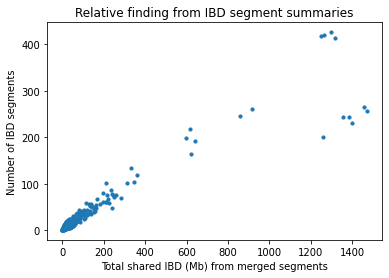

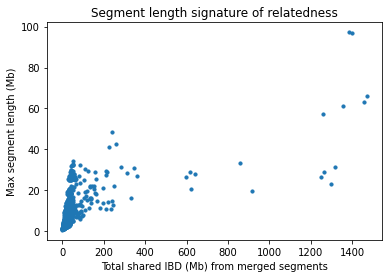

In [8]:
import matplotlib.pyplot as plt

# Plot 1: total shared Mb vs number of segments
plt.figure()
plt.scatter(pair_stats["total_mb_merged"], pair_stats["nseg_raw"], s=10)
plt.xlabel("Total shared IBD (Mb) from merged segments")
plt.ylabel("Number of IBD segments")
plt.title("Relative finding from IBD segment summaries")
plt.show()

# Plot 2: total shared Mb vs max segment
plt.figure()
plt.scatter(pair_stats["total_mb_merged"], pair_stats["max_seg_mb_raw"], s=10)
plt.xlabel("Total shared IBD (Mb) from merged segments")
plt.ylabel("Max segment length (Mb)")
plt.title("Segment length signature of relatedness")
plt.show()